# Monthly Reversal Swing startegy (MRS)

Strategy Rules:
1) Strategy for Nifty-50 stocks only
2) Find the stocks which have formed 3 or more than 3 mid size red candles on monthly timeframe
3) Find suceeding months closing candle(If it is green candle go to step 4 else ignore the setup)
4) Take entry on next day(i+1) of green candles opening. keep R:R = 1:2
5) Keep Stoploss on closing basis of swing low

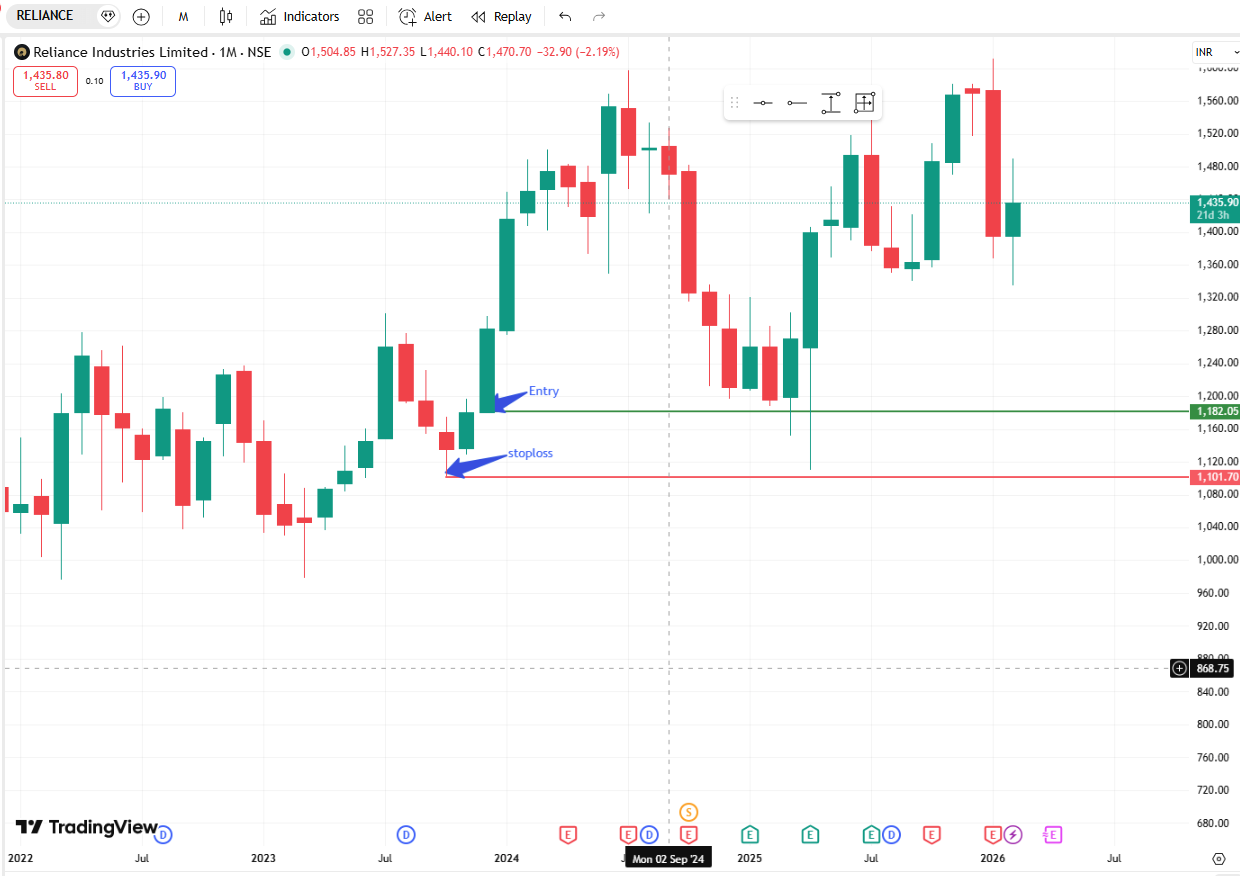

In [10]:
import pandas as pd
from fyers_apiv3 import fyersModel
import pytz
import datetime as dt

client_id = open("../client_ID.txt",'r').read()
access_token = open("../access_token.txt",'r').read()

fyers = fyersModel.FyersModel(client_id=client_id, is_async=False, token=access_token, log_path="D:\FyiersApiAutomation\logs")

def fetchOHLC(ticker, interval, range_from, range_to):
    
    from_date = dt.datetime.strptime(range_from, "%Y-%m-%d").date()
    to_date = dt.datetime.strptime(range_to, "%Y-%m-%d").date()

     # create a datafarme
    columns = ['UTCTime','Open','High','Low','Close', 'Volume']
    df = pd.DataFrame(columns=columns,)

    current_from = from_date

    while True:

        from_date_string = current_from.strftime("%Y-%m-%d")
        
        if current_from >= (to_date - dt.timedelta(days=50)):
            to_date_string = to_date.strftime("%Y-%m-%d")

            data = {
                "symbol":ticker,
                "resolution":interval,
                "date_format":"1",
                "range_from":from_date_string,
                "range_to":to_date_string,
                "cont_flag":"1"
            }
            resp = fyers.history(data=data)['candles']                                                                                 
            df1 = pd.DataFrame(resp, columns=columns)
            df = pd.concat([df, df1], ignore_index=True)
            break
        else:
            current_to = current_from + dt.timedelta(days=50)
            to_date_string = current_to.strftime("%Y-%m-%d")
            data = {
                "symbol":ticker,
                "resolution":interval,
                "date_format":"1",
                "range_from":from_date_string,
                "range_to":to_date_string,
                "cont_flag":"1"
            }
            resp = fyers.history(data=data)['candles']
            df1 = pd.DataFrame(resp, columns=columns)
            df = pd.concat([df, df1], ignore_index=True)
            current_from = current_to + dt.timedelta(days=1)
   
   # Remove duplicates
    df = df.drop_duplicates(subset=['UTCTime'], keep='first')
    
    # Converting UTC time to datetime
    df['Datetime'] = pd.to_datetime(df['UTCTime'], unit='s').dt.tz_localize(pytz.utc)

    # Converting datetime to IST
    ist = pytz.timezone('Asia/Kolkata')
    df['Datetime'] = df['Datetime'].dt.tz_convert(ist)

    # Creating Monthly candle data from Daily data
    monthly = df.groupby(pd.Grouper(key='Datetime', freq='ME')).agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    }).reset_index()

    monthly = monthly.drop('Volume', axis=1)
    return monthly



In [11]:
# Function to find 3 or more than 3 continuous monthly red candles
def find_consecutive_red_candles(df, min_consecutive=3):
    """
    Find patterns where there are 3 or more consecutive red candles
    Returns list of pattern dictionaries with CORRECT key names
    """
    df = df.copy().reset_index(drop=True)
    
    # Check if 'Month' column exists
    if 'Month' not in df.columns:
        if 'Datetime' in df.columns:
            df['Month'] = df['Datetime']
        elif 'Date' in df.columns:
            df['Month'] = df['Date']
        else:
            df['Month'] = df.index
    
    # Check required columns
    required_cols = ['Open', 'High', 'Low', 'Close']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    
    df['is_red'] = df['Close'] < df['Open']
    
    print(f"\nTotal candles: {len(df)}")
    print(f"Red candles: {df['is_red'].sum()}")
    print(f"Green candles: {(~df['is_red']).sum()}")
    
    patterns = []
    consecutive_count = 0
    current_pattern_start = None
    
    for idx in range(len(df)):
        row = df.iloc[idx]
        
        if row['is_red']:
            if consecutive_count == 0:
                current_pattern_start = idx
            consecutive_count += 1
        else:
            # End of red candles streak
            if consecutive_count >= min_consecutive:
                # Get the lowest low from all red candles in the pattern
                pattern_slice = df.iloc[current_pattern_start:idx]
                pattern_low = pattern_slice['Low'].min()
                
                pattern_dict = {
                    'pattern_end_index': idx - 1,          # CORRECT KEY NAME
                    'pattern_start_index': current_pattern_start,  # CORRECT KEY NAME
                    'consecutive_red_candles': consecutive_count,
                    'pattern_end_date': df.iloc[idx - 1]['Month'],
                    'pattern_low': pattern_low
                }
                
                patterns.append(pattern_dict)
                print(f"  Pattern found: {consecutive_count} consecutive reds from index {current_pattern_start} to {idx-1}")
            
            consecutive_count = 0
            current_pattern_start = None
    
    # Check if pattern continues till the end
    if consecutive_count >= min_consecutive:
        pattern_slice = df.iloc[current_pattern_start:]
        pattern_low = pattern_slice['Low'].min()
        
        pattern_dict = {
            'pattern_end_index': len(df) - 1,              # CORRECT KEY NAME
            'pattern_start_index': current_pattern_start,  # CORRECT KEY NAME
            'consecutive_red_candles': consecutive_count,
            'pattern_end_date': df.iloc[-1]['Month'],
            'pattern_low': pattern_low
        }
        
        patterns.append(pattern_dict)
        print(f"  Pattern found: {consecutive_count} consecutive reds from index {current_pattern_start} to {len(df)-1} (ongoing)")
    
    print(f"\nTotal patterns found: {len(patterns)}")
    return patterns
    

In [12]:
import glob
import os
import pandas as pd
import numpy as np

def load_nifty50_from_csv(csv_folder_path):
    print("\n" + "="*80)
    print("LOADING DATA FROM CSV FILES")
    print("="*80)

    # Find all CSV files matching the pattern
    pattern = os.path.join(csv_folder_path, "NSE_*_EQ_monthly_OHLC.csv")
    csv_files = glob.glob(pattern)

    if not csv_files:
        print(f"❌ No CSV files found matching pattern: {pattern}")
        print(f"Looking in: {os.path.abspath(csv_folder_path)}")
        return {}

    print(f"Found {len(csv_files)} CSV files")
    print("-"*80)

    stock_data = {}
    failed_files = []

    for csv_file in csv_files:
        try:
            # Extract symbol from filename
            # NSE_ADANIENT_EQ_monthly_OHLC.csv -> ADANIENT
            filename = os.path.basename(csv_file)
            parts = filename.replace('.csv', '').split('_')
            
            if len(parts) >= 3:
                symbol = parts[1]  # Get the symbol part
                ticker = f"NSE:{symbol}-EQ"  # Format as NSE:SYMBOL-EQ
            else:
                print(f"⚠ Skipping {filename}: unexpected filename format")
                failed_files.append((filename, "Invalid filename format"))
                continue

            # Read CSV file
            df = pd.read_csv(csv_file)
            df['Month'] = pd.to_datetime(df['Datetime'])
            

            df = df[['Month', 'Open', 'High', 'Low', 'Close']].copy()
            
            # Remove any NaN rows
            df = df.dropna()

            #Sort by date
            df = df.sort_values('Month').reset_index(drop=True)

            # Store in dictionary
            stock_data[ticker] = df
            print(f"✓ {ticker:.<30} {len(df)} months")
        
        except Exception as e:
            print(f"✗ Error loading {filename}: {str(e)[:60]}")
            failed_files.append((filename, str(e)[:60]))

            print("\n" + "="*80)
            print(f"Successfully loaded: {len(stock_data)}/{len(csv_files)} files")
            stock_data.insert("File loaded for :", ticker)

    return stock_data



In [ ]:
class PortfolioBacktester:
    """
    Portfolio-level backtester with strict position limit enforcement
    Maximum 5 simultaneous open positions at any time
    """
    
    def __init__(self, 
                 initial_capital=1000000,
                 max_positions=5,
                 position_size=0.2,
                 brokerage=0.0003,
                 slippage=0.001,
                 min_consecutive=3,
                 risk_reward_ratio=2):
        
        self.initial_capital = initial_capital
        self.max_positions = max_positions
        self.position_size = position_size
        self.brokerage = brokerage
        self.slippage = slippage
        self.min_consecutive = min_consecutive
        self.risk_reward_ratio = risk_reward_ratio
        
        # Portfolio tracking
        self.portfolio_equity = []
        self.all_trades = []
        self.daily_returns = []
    
    
    def backtest_single_stock(self, ticker, monthly_df):
        """
        Identify potential trade setups for a single stock
        Returns: list of trade setups (not executed yet)
        """
        if monthly_df.empty or len(monthly_df) < 5:
            return []
        
        df = monthly_df.copy().reset_index(drop=True)
        
        # Ensure Month column exists
        if 'Month' not in df.columns:
            if 'Datetime' in df.columns:
                df['Month'] = df['Datetime']
            elif 'Date' in df.columns:
                df['Month'] = df['Date']
        
        patterns = find_consecutive_red_candles(df, self.min_consecutive)
        trade_setups = []
        
        for pattern in patterns:
            pattern_end_idx = pattern['pattern_end_index']
            
            if pattern_end_idx + 1 >= len(df):
                continue
            
            next_candle_idx = pattern_end_idx + 1
            next_candle = df.iloc[next_candle_idx]
            
            # Green confirmation
            is_green = next_candle['Close'] > next_candle['Open']
            
            if is_green:
                if next_candle_idx + 1 >= len(df):
                    continue
                
                entry_idx = next_candle_idx + 1
                entry_candle = df.iloc[entry_idx]
                
                # Calculate trade parameters
                entry_price = entry_candle['Open']
                entry_price_actual = entry_price * (1 + self.slippage)
                stop_loss = pattern['pattern_low']
                risk = entry_price_actual - stop_loss
                
                if risk <= 0:
                    continue
                
                target = entry_price_actual + (risk * self.risk_reward_ratio)
                
                # Create trade setup (not executed yet)
                setup = {
                    'ticker': ticker,
                    'entry_date': entry_candle['Month'],
                    'entry_price': entry_price_actual,
                    'stop_loss': stop_loss,
                    'target': target,
                    'risk': risk,
                    'consecutive_reds': pattern['consecutive_red_candles'],
                    'pattern_end_idx': pattern_end_idx,
                    'entry_idx': entry_idx,
                    'df': df  # Keep reference to check future candles
                }
                
                trade_setups.append(setup)
        
        return trade_setups
    
    
    def run_portfolio_backtest(self, stock_data_dict):
        """
        Run backtest with strict position limit enforcement
        Maximum 5 positions open at any time
        """
        print("\n" + "="*80)
        print("RUNNING PORTFOLIO BACKTEST WITH POSITION LIMITS")
        print("="*80)
        print(f"Max simultaneous positions: {self.max_positions}")
        
        # Step 1: Collect all potential trade setups from all stocks
        all_setups = []
        
        for ticker, monthly_df in stock_data_dict.items():
            print(f"Scanning {ticker}...", end=" ")
            setups = self.backtest_single_stock(ticker, monthly_df)
            all_setups.extend(setups)
            print(f"{len(setups)} setups found")
        
        print(f"\nTotal potential setups across all stocks: {len(all_setups)}")
        
        if not all_setups:
            print("❌ No trade setups found")
            return []
        
        # Step 2: Sort setups by entry date
        all_setups.sort(key=lambda x: x['entry_date'])
        
        print(f"Date range: {all_setups[0]['entry_date']} to {all_setups[-1]['entry_date']}")
        
        # Step 3: Simulate portfolio with position limits
        executed_trades = []
        open_positions = []  # Currently open trades
        rejected_setups = 0
        
        print("\n" + "="*80)
        print("SIMULATING TRADES WITH POSITION LIMITS")
        print("="*80)
        
        for setup in all_setups:
            entry_date = setup['entry_date']
            
            # Check and close any positions that hit SL/Target before this entry date
            open_positions = self.update_open_positions(open_positions, entry_date)
            
            # Check if we have room for a new position
            if len(open_positions) >= self.max_positions:
                rejected_setups += 1
                continue  # Skip this setup, portfolio is full
            
            # Execute the trade
            trade = self.execute_trade(setup)
            
            # Add to open positions
            open_positions.append(trade)
            executed_trades.append(trade)
            
            print(f"[{len(executed_trades)}] {trade['ticker']} @ {trade['entry_date'].strftime('%Y-%m-%d')} | "
                  f"Open positions: {len(open_positions)}/{self.max_positions}")
        
        # Close any remaining open positions at the end
        for trade in open_positions:
            if trade['status'] == 'Open':
                trade['status'] = 'Open (EOD)'  # Still open at end of data
        
        print("\n" + "="*80)
        print("BACKTEST SUMMARY")
        print("="*80)
        print(f"Total setups identified: {len(all_setups)}")
        print(f"Trades executed: {len(executed_trades)}")
        print(f"Setups rejected (portfolio full): {rejected_setups}")
        print(f"Rejection rate: {rejected_setups/len(all_setups)*100:.1f}%")
        
        self.all_trades = executed_trades
        return executed_trades
    
    
    def update_open_positions(self, open_positions, current_date):
        """
        Check if any open positions hit SL or Target before current_date
        Remove closed positions from open_positions list
        """
        still_open = []
        
        for trade in open_positions:
            if trade['status'] != 'Open':
                continue  # Already closed
            
            # Check candles after entry until current_date
            df = trade['df']
            entry_idx = trade['entry_idx']
            
            # Find candles between entry and current_date
            for i in range(entry_idx + 1, len(df)):
                candle = df.iloc[i]
                candle_date = candle['Month']
                
                # Stop checking if we've reached current_date
                if candle_date >= current_date:
                    break
                
                # Check if stop loss hit
                if candle['Low'] <= trade['stop_loss']:
                    exit_price = trade['stop_loss'] * (1 - self.slippage)
                    exit_value = trade['shares'] * exit_price
                    exit_cost = exit_value * self.brokerage
                    
                    trade['status'] = 'Loss'
                    trade['exit_price'] = exit_price
                    trade['exit_date'] = candle_date
                    trade['exit_cost'] = exit_cost
                    trade['pnl'] = exit_value - trade['position_value'] - trade['entry_cost'] - exit_cost
                    trade['pnl_percent'] = (trade['pnl'] / trade['position_value']) * 100
                    trade['return_on_capital'] = (trade['pnl'] / self.initial_capital) * 100
                    break
                
                # Check if target hit
                if candle['High'] >= trade['target']:
                    exit_price = trade['target'] * (1 - self.slippage)
                    exit_value = trade['shares'] * exit_price
                    exit_cost = exit_value * self.brokerage
                    
                    trade['status'] = 'Win'
                    trade['exit_price'] = exit_price
                    trade['exit_date'] = candle_date
                    trade['exit_cost'] = exit_cost
                    trade['pnl'] = exit_value - trade['position_value'] - trade['entry_cost'] - exit_cost
                    trade['pnl_percent'] = (trade['pnl'] / trade['position_value']) * 100
                    trade['return_on_capital'] = (trade['pnl'] / self.initial_capital) * 100
                    break
            
            # If still open, keep it in the list
            if trade['status'] == 'Open':
                still_open.append(trade)
        
        return still_open
    
    
    def execute_trade(self, setup):
        """
        Execute a trade setup and create a trade record
        """
        # Calculate position sizing
        position_value = self.initial_capital * self.position_size
        shares = position_value / setup['entry_price']
        entry_cost = position_value * self.brokerage
        
        trade = {
            'ticker': setup['ticker'],
            'entry_date': setup['entry_date'],
            'entry_price': setup['entry_price'],
            'stop_loss': setup['stop_loss'],
            'target': setup['target'],
            'shares': shares,
            'position_value': position_value,
            'entry_cost': entry_cost,
            'risk': setup['risk'],
            'consecutive_reds': setup['consecutive_reds'],
            'status': 'Open',
            'exit_price': None,
            'exit_date': None,
            'exit_cost': 0,
            'pnl': 0,
            'pnl_percent': 0,
            'return_on_capital': 0,
            'entry_idx': setup['entry_idx'],
            'df': setup['df']
        }
        
        return trade
    
    def calculate_metrics(self):
        """Calculate comprehensive performance metrics"""
        
        if not self.all_trades:
            return {}
        
        trades_df = pd.DataFrame(self.all_trades)
        
        # Separate completed and open trades
        completed_trades = trades_df[trades_df['status'].isin(['Win', 'Loss'])]
        open_trades = trades_df[~trades_df['status'].isin(['Win', 'Loss'])]
        
        total_trades = len(completed_trades)
        winning_trades = len(completed_trades[completed_trades['status'] == 'Win'])
        losing_trades = len(completed_trades[completed_trades['status'] == 'Loss'])
        still_open = len(open_trades)
        
        win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0
        
        # PnL metrics (only from completed trades)
        total_pnl = completed_trades['pnl'].sum() if total_trades > 0 else 0
        total_return_pct = (total_pnl / self.initial_capital) * 100
        
        avg_win = completed_trades[completed_trades['status'] == 'Win']['pnl'].mean() if winning_trades > 0 else 0
        avg_loss = completed_trades[completed_trades['status'] == 'Loss']['pnl'].mean() if losing_trades > 0 else 0
        
        # Risk metrics
        avg_rr = abs(avg_win / avg_loss) if avg_loss != 0 else 0
        expectancy = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss) if total_trades > 0 else 0
        
        # Profit factor
        gross_profit = completed_trades[completed_trades['pnl'] > 0]['pnl'].sum()
        gross_loss = abs(completed_trades[completed_trades['pnl'] < 0]['pnl'].sum())
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else 0
        
        # Calculate equity curve and drawdown (only from completed trades)
        equity_curve = [self.initial_capital]
        for _, trade in completed_trades.sort_values('exit_date').iterrows():
            equity_curve.append(equity_curve[-1] + trade['pnl'])
        
        equity_series = pd.Series(equity_curve)
        running_max = equity_series.cummax()
        drawdown = (equity_series - running_max) / running_max * 100
        max_drawdown = drawdown.min()
        
        # Calculate CAGR
        if total_trades > 0:
            start_date = pd.to_datetime(completed_trades['entry_date'].min())
            end_date = pd.to_datetime(completed_trades['exit_date'].max())
            years = (end_date - start_date).days / 365.25
            
            final_equity = equity_curve[-1]
            cagr = (((final_equity / self.initial_capital) ** (1/years)) - 1) * 100 if years > 0 else 0
        else:
            cagr = 0
        
        # Sharpe Ratio
        trade_returns = completed_trades['return_on_capital']
        sharpe = (trade_returns.mean() / trade_returns.std()) * np.sqrt(12) if len(trade_returns) > 1 and trade_returns.std() > 0 else 0
        
        metrics = {
            'Initial Capital': self.initial_capital,
            'Final Equity': equity_curve[-1] if equity_curve else self.initial_capital,
            'Total PnL': round(total_pnl, 2),
            'Total Return (%)': round(total_return_pct, 2),
            'CAGR (%)': round(cagr, 2),
            'Total Setups': len(self.all_trades),
            'Completed Trades': total_trades,
            'Winning Trades': winning_trades,
            'Losing Trades': losing_trades,
            'Still Open': still_open,
            'Win Rate (%)': round(win_rate, 2),
            'Avg Win (₹)': round(avg_win, 2),
            'Avg Loss (₹)': round(avg_loss, 2),
            'Actual R:R': round(avg_rr, 2),
            'Expectancy (₹)': round(expectancy, 2),
            'Profit Factor': round(profit_factor, 2),
            'Max Drawdown (%)': round(max_drawdown, 2),
            'Sharpe Ratio': round(sharpe, 2),
            'Total Costs (₹)': round(completed_trades['entry_cost'].sum() + completed_trades['exit_cost'].sum(), 2),
            'Max Positions Used': self.max_positions
        }
        
        self.equity_curve = equity_curve
        self.drawdown_series = drawdown
        
        return metrics

In [26]:
def plot_equity_curve(equity_curve, initial_capital, title="Portfolio Equity Curve"):
    """Plot portfolio equity over time"""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    equity_series = pd.Series(equity_curve)
    ax.plot(equity_series.index, equity_series.values, linewidth=2, color='#2E86AB', label='Portfolio Equity')
    ax.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.7, label='Initial Capital')
    ax.fill_between(equity_series.index, initial_capital, equity_series.values, 
                     where=(equity_series.values >= initial_capital), alpha=0.3, color='green', interpolate=True)
    ax.fill_between(equity_series.index, initial_capital, equity_series.values, 
                     where=(equity_series.values < initial_capital), alpha=0.3, color='red', interpolate=True)
    
    ax.set_xlabel('Trade Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Equity (₹)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


def plot_drawdown(drawdown_series, title="Portfolio Drawdown"):
    """Plot drawdown over time"""
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.fill_between(drawdown_series.index, 0, drawdown_series.values, 
                     alpha=0.6, color='crimson', label='Drawdown')
    ax.plot(drawdown_series.index, drawdown_series.values, linewidth=2, color='darkred')
    
    ax.set_xlabel('Trade Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Drawdown (%)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


def plot_trade_distribution(trades_df, title="Trade PnL Distribution"):
    """Plot histogram of trade returns"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # PnL distribution
    pnl_data = trades_df[trades_df['status'] != 'Open']['pnl']
    ax1.hist(pnl_data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even')
    ax1.axvline(x=pnl_data.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: ₹{pnl_data.mean():.0f}')
    ax1.set_xlabel('PnL (₹)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('PnL Distribution', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Win/Loss pie chart
    status_counts = trades_df[trades_df['status'] != 'Open']['status'].value_counts()
    colors = ['#28a745', '#dc3545']
    ax2.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax2.set_title('Win/Loss Distribution', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    return fig


def plot_monthly_returns_heatmap(trades_df, title="Monthly Returns Heatmap"):
    """Create heatmap of monthly returns"""
    completed_trades = trades_df[trades_df['status'] != 'Open'].copy()
    
    if completed_trades.empty:
        print("No completed trades for heatmap")
        return None
    
    completed_trades['exit_date'] = pd.to_datetime(completed_trades['exit_date'])
    completed_trades['year'] = completed_trades['exit_date'].dt.year
    completed_trades['month'] = completed_trades['exit_date'].dt.month
    
    monthly_returns = completed_trades.groupby(['year', 'month'])['pnl'].sum().reset_index()
    pivot_table = monthly_returns.pivot(index='month', columns='year', values='pnl')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='RdYlGn', center=0, 
                cbar_kws={'label': 'PnL (₹)'}, linewidths=0.5, ax=ax)
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Month', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    plt.tight_layout()
    return fig


def create_summary_report(metrics, trades_df):
    """Create a text summary report with position limit info"""
    report = []
    report.append("="*80)
    report.append("NIFTY 50 REVERSAL STRATEGY - BACKTEST REPORT")
    report.append("="*80)
    report.append("")
    report.append("STRATEGY DESCRIPTION:")
    report.append("-"*80)
    report.append("Entry Signal: 3+ consecutive monthly red candles followed by 1 green candle")
    report.append("Entry: Open of the month after green confirmation candle")
    report.append("Stop Loss: Lowest low of the red candle pattern")
    report.append("Target: Entry + 2x Risk (1:2 Risk:Reward)")
    report.append(f"Position Size: {metrics.get('Max Positions Used', 5) * 15}% of capital (15% per position)")
    report.append(f"Max Simultaneous Positions: {metrics.get('Max Positions Used', 5)}")
    report.append("Transaction Costs: 0.03% brokerage + 0.1% slippage per trade")
    report.append("")
    
    # Add rejection info if available
    if 'Total Setups' in metrics and 'Completed Trades' in metrics:
        total_setups = metrics['Total Setups']
        completed = metrics['Completed Trades']
        rejected = total_setups - completed
        rejection_rate = (rejected / total_setups * 100) if total_setups > 0 else 0
        
        report.append("POSITION LIMIT IMPACT:")
        report.append("-"*80)
        report.append(f"Total Setups Identified: {total_setups}")
        report.append(f"Trades Executed: {completed}")
        report.append(f"Setups Rejected (Portfolio Full): {rejected}")
        report.append(f"Rejection Rate: {rejection_rate:.1f}%")
        report.append("")
    
    report.append("="*80)
    report.append("PERFORMANCE METRICS")
    report.append("="*80)
    
    for key, value in metrics.items():
        if isinstance(value, (int, float)):
            if 'Capital' in key or 'PnL' in key or 'Equity' in key or 'Win' in key or 'Loss' in key or 'Costs' in key:
                report.append(f"{key:.<40} ₹{value:,.2f}")
            else:
                report.append(f"{key:.<40} {value:,.2f}")
        else:
            report.append(f"{key:.<40} {value}")
    
    report.append("")
    report.append("="*80)
    report.append("TRADE ANALYSIS")
    report.append("="*80)
    
    if not trades_df.empty:
        completed = trades_df[trades_df['status'].isin(['Win', 'Loss'])]
        
        if not completed.empty:
            report.append(f"Best Trade: ₹{completed['pnl'].max():,.2f} ({completed['pnl_percent'].max():.2f}%)")
            report.append(f"Worst Trade: ₹{completed['pnl'].min():,.2f} ({completed['pnl_percent'].min():.2f}%)")
            report.append(f"Average Trade: ₹{completed['pnl'].mean():,.2f} ({completed['pnl_percent'].mean():.2f}%)")
            report.append(f"Median Trade: ₹{completed['pnl'].median():,.2f}")
            
            # Stock distribution
            report.append("")
            report.append("TOP 5 PERFORMING STOCKS:")
            report.append("-"*80)
            stock_pnl = completed.groupby('ticker')['pnl'].sum().sort_values(ascending=False).head(5)
            for ticker, pnl in stock_pnl.items():
                report.append(f"  {ticker:.<35} ₹{pnl:,.2f}")
            
            report.append("")
            report.append("BOTTOM 5 PERFORMING STOCKS:")
            report.append("-"*80)
            stock_pnl_bottom = completed.groupby('ticker')['pnl'].sum().sort_values().head(5)
            for ticker, pnl in stock_pnl_bottom.items():
                report.append(f"  {ticker:.<35} ₹{pnl:,.2f}")
    
    report.append("")
    report.append("="*80)
    report.append("LIMITATIONS & CONSIDERATIONS")
    report.append("="*80)
    report.append("• Monthly timeframe = limited sample size")
    report.append("• Position limits reduce total trades executed")
    report.append("• Backtest includes survivorship bias")
    report.append("• Market regime dependency not accounted for")
    report.append("• Assumes sufficient liquidity for all trades")
    report.append("="*80)
    
    return "\n".join(report)

In [30]:
def main():
    """Main execution function for the complete backtest"""
    
    print("\n" + "="*80)
    print("NIFTY 50 REVERSAL STRATEGY BACKTEST")
    print("="*80)
    print("\nStrategy: Buy after 3+ consecutive red monthly candles + green confirmation")
    print("Period: 2022-01-01 to 2025-12-31")
    print("Universe: Nifty 50 stocks")
    print("\n" + "="*80)
    
    # Step 1: Fetch data for all Nifty 50 stocks
    print("\nSTEP 1: FETCHING DATA")
    print("="*80)
    
    try:
        csv_folder_path = "D:\FyiersApiAutomation\swing-trading_strategies\monthly_symbol_data"
        stock_data = load_nifty50_from_csv(csv_folder_path)
    except Exception as e:
        print(f"❌ Error fetching data: {e}")
        return None, None, None
    
    if not stock_data or len(stock_data) == 0:
        print("❌ No data fetched. Please check your Fyers API credentials.")
        print("Tip: Make sure 'fyers' object is initialized with valid credentials")
        return None, None, None
    
    # Step 2: Initialize backtester
    print("\nSTEP 2: INITIALIZING BACKTESTER")
    print("="*80)
    
    backtester = PortfolioBacktester(
        initial_capital=1000000,      # 10 Lakhs
        max_positions=5,              # Max 5 trades at once
        position_size=0.2,           # 15% per trade
        brokerage=0.0003,             # 0.03%
        slippage=0.001,               # 0.1%
        min_consecutive=3,            # 3+ red candles
        risk_reward_ratio=2           # 1:2 R:R
    )
    
    print(f"Initial Capital: ₹{backtester.initial_capital:,}")
    print(f"Position Size: {backtester.position_size*100}%")
    print(f"Max Positions: {backtester.max_positions}")
    print(f"Transaction Costs: {backtester.brokerage*100}% brokerage + {backtester.slippage*100}% slippage")
    
    # Step 3: Run backtest
    print("\nSTEP 3: RUNNING BACKTEST")
    try:
        all_trades = backtester.run_portfolio_backtest(stock_data)
    except Exception as e:
        print(f"❌ Error during backtest: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None
    
    if not all_trades or len(all_trades) == 0:
        print("❌ No trades generated. This could mean:")
        print("  • No patterns found in the data")
        print("  • All patterns were at the end of data (no room for confirmation)")
        print("  • Data quality issues")
        return None, None, None
    
    # Step 4: Calculate metrics
    print("\nSTEP 4: CALCULATING METRICS")
    print("="*80)
    
    try:
        metrics = backtester.calculate_metrics()
    except Exception as e:
        print(f"❌ Error calculating metrics: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None
    
    if not metrics:
        print("❌ Failed to calculate metrics")
        return None, None, None
    
    # Step 5: Create visualizations
    print("\nSTEP 5: GENERATING VISUALIZATIONS")
    print("="*80)
    
    trades_df = pd.DataFrame(all_trades)
    
    try:
        # Equity curve
        fig1 = plot_equity_curve(backtester.equity_curve, backtester.initial_capital)
        fig1.savefig('equity_curve.png', dpi=300, bbox_inches='tight')
        print("✓ Saved: equity_curve.png")
        plt.close(fig1)
        
        # Drawdown
        fig2 = plot_drawdown(backtester.drawdown_series)
        fig2.savefig('drawdown.png', dpi=300, bbox_inches='tight')
        print("✓ Saved: drawdown.png")
        plt.close(fig2)
        
        # Trade distribution
        fig3 = plot_trade_distribution(trades_df)
        fig3.savefig('trade_distribution.png', dpi=300, bbox_inches='tight')
        print("✓ Saved: trade_distribution.png")
        plt.close(fig3)
        
        # Monthly heatmap
        fig4 = plot_monthly_returns_heatmap(trades_df)
        if fig4:
            fig4.savefig('monthly_returns_heatmap.png', dpi=300, bbox_inches='tight')
            print("✓ Saved: monthly_returns_heatmap.png")
            plt.close(fig4)
    
    except Exception as e:
        print(f"⚠ Warning: Error generating some visualizations: {e}")
    
    # Step 6: Generate report
    print("\nSTEP 6: GENERATING REPORT")
    print("="*80)
    
    try:
        report = create_summary_report(metrics, trades_df)
        print(report)
        
        # Save report to file
        with open('backtest_report.txt', 'w') as f:
            f.write(report)
        print("\n✓ Saved: backtest_report.txt")
        
        # Save trades to CSV
        trades_df.to_csv('all_trades.csv', index=False)
        print("✓ Saved: all_trades.csv")
    
    except Exception as e:
        print(f"⚠ Warning: Error generating report: {e}")
    
    # Step 7: Print summary
    print("\n" + "="*80)
    print("BACKTEST COMPLETE!")
    print("="*80)
    print(f"\nFiles generated:")
    print("  • equity_curve.png")
    print("  • drawdown.png")
    print("  • trade_distribution.png")
    print("  • monthly_returns_heatmap.png")
    print("  • backtest_report.txt")
    print("  • all_trades.csv")
    print("\nKey Metrics:")
    print(f"  Total Return: {metrics.get('Total Return (%)', 'N/A')}%")
    print(f"  CAGR: {metrics.get('CAGR (%)', 'N/A')}%")
    print(f"  Sharpe Ratio: {metrics.get('Sharpe Ratio', 'N/A')}")
    print(f"  Max Drawdown: {metrics.get('Max Drawdown (%)', 'N/A')}%")
    print(f"  Win Rate: {metrics.get('Win Rate (%)', 'N/A')}%")
    print(f"  Total Trades: {metrics.get('Total Trades', 'N/A')}")
    
    return backtester, trades_df, metrics


# Now call the function
backtester, trades_df, metrics = main()


NIFTY 50 REVERSAL STRATEGY BACKTEST

Strategy: Buy after 3+ consecutive red monthly candles + green confirmation
Period: 2022-01-01 to 2025-12-31
Universe: Nifty 50 stocks


STEP 1: FETCHING DATA

LOADING DATA FROM CSV FILES
Found 48 CSV files
--------------------------------------------------------------------------------
✓ NSE:ADANIENT-EQ............... 37 months
✓ NSE:ADANIPORTS-EQ............. 37 months
✓ NSE:APOLLOHOSP-EQ............. 37 months
✓ NSE:ASIANPAINT-EQ............. 37 months
✓ NSE:AXISBANK-EQ............... 37 months
✓ NSE:BAJAJFINSV-EQ............. 37 months
✓ NSE:BAJAJ-EQ.................. 37 months
✓ NSE:BAJFINANCE-EQ............. 37 months
✓ NSE:BHARTIARTL-EQ............. 37 months
✓ NSE:BPCL-EQ................... 37 months
✓ NSE:BRITANNIA-EQ.............. 37 months
✓ NSE:CIPLA-EQ.................. 37 months
✓ NSE:COALINDIA-EQ.............. 37 months
✓ NSE:DIVISLAB-EQ............... 37 months
✓ NSE:DRREDDY-EQ................ 37 months
✓ NSE:EICHERMOT-EQ...........

In [ ]:
print(trades_df)
trades_df.to_csv("all_trades.csv",index=False)